In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from transformers import AutoImageProcessor, DINOv3ViTModel, T5Tokenizer, T5EncoderModel
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import torchmetrics as tm
import os

In [2]:
root_path = "/home/stefan/ioai-prep/kits/rooms"
seed = 42
device = "cuda" if torch.cuda.is_available() else "cpu"

In [3]:
image_processor = AutoImageProcessor.from_pretrained("facebook/dinov3-vitb16-pretrain-lvd1689m")
dino_model = DINOv3ViTModel.from_pretrained("facebook/dinov3-vitb16-pretrain-lvd1689m")

tokenizer = T5Tokenizer.from_pretrained("t5-small")
t5_model = T5EncoderModel.from_pretrained("t5-small")

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


# Data

In [4]:
train_df = pd.read_csv(f"{root_path}/train.csv")
test_df = pd.read_csv(f"{root_path}/test.csv")

train_df = train_df[train_df["question"].str.len() <= 77]
train_df = train_df[train_df["question"].str.startswith("how many")]

In [5]:
class CountingVQADataset(Dataset):
    def __init__(self, df, image_processor, tokenizer):
        self.df = df.reset_index(drop=True)
        self.df["question"] = self.df["question"].apply(
            lambda x: x[0].upper() + x[1:] + "?"
        )
        self.image_dir = f"{root_path}/images"
        self.image_processor = image_processor
        self.tokenizer = tokenizer

        self.augment = transforms.Compose(
            [
                transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
            ]
        )

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_path = os.path.join(self.image_dir, f"{row['image_id']}.png")
        image = Image.open(image_path).convert("RGB")
        question = row["question"]
        answer = row["answer"] if "answer" in self.df.columns else 0.0

        if "answer" in self.df.columns:
            image = self.augment(image)

        pixel_values = self.image_processor(images=image, return_tensors="pt")[
            "pixel_values"
        ].squeeze(0)
        tokens = self.tokenizer(
            text=question,
            max_length=77,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        return {
            "pixel_values": pixel_values,
            "input_ids": tokens["input_ids"].squeeze(0),
            "attention_mask": tokens["attention_mask"].squeeze(0),
            "answer": torch.tensor(answer, dtype=torch.float32),
        }

    def __len__(self):
        return len(self.df)

In [6]:
train_df, val_df = train_test_split(train_df, test_size=0.2, random_state=seed)

train_dataset = CountingVQADataset(train_df, image_processor, tokenizer)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, drop_last=True)

val_dataset = CountingVQADataset(val_df, image_processor, tokenizer)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=True, drop_last=True)

In [7]:
batch = next(iter(train_loader))
{k: batch[k].shape for k in batch.keys()}

{'pixel_values': torch.Size([32, 3, 224, 224]),
 'input_ids': torch.Size([32, 77]),
 'attention_mask': torch.Size([32, 77]),
 'answer': torch.Size([32])}

In [8]:
len(train_df)

1040

# Model

In [ ]:
class RefinedSpatialFiLM(nn.Module):
    def __init__(self, d_text, d_vis_channels):
        super().__init__()
        # Keep this small to prevent overfitting
        self.gen = nn.Linear(d_text, d_vis_channels * 2)

    def forward(self, vis_map, txt):
        # Broadcast text features across spatial dimensions
        g = self.gen(txt).unsqueeze(-1).unsqueeze(-1)
        gamma, beta = g.chunk(2, dim=1)
        return torch.sigmoid(gamma) * vis_map + beta


class SmallCNN(nn.Module):
    def __init__(self, out_channels=256):
        super().__init__()

        # Shallow network with Batchnorm to stabilize training from scratch
        def block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 3, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU(),
                nn.MaxPool2d(2),
            )

        self.net = nn.Sequential(
            block(3, 32),  # 112x112 (assuming 224 input)
            block(32, 64),  # 56x56
            block(64, 128),  # 28x28
            block(128, out_channels),  # 14x14
        )

    def forward(self, x):
        return self.net(x)


class SmallLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=256):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        # Dropout added to prevent overfitting to question text
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, dropout=0.1)

    def forward(self, input_ids, attention_mask):
        x = self.embedding(input_ids)
        lengths = attention_mask.sum(dim=1).detach().cpu()
        packed = nn.utils.rnn.pack_padded_sequence(
            x, lengths, batch_first=True, enforce_sorted=False
        )
        _, (h_n, _) = self.lstm(packed)
        return h_n[-1]


class VQAModel(nn.Module):
    def __init__(self, d_v=256, d_t=256):
        super().__init__()
        

    def forward(self, pixel_values, input_ids, attention_mask):
        pass

In [ ]:
model = VQAModel().to(device)

/home/stefan/.local/lib/python3.13/site-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  warnings.warn(


MultimodalVQAModel(
  (vision_encoder): SmallCNN(
    (net): Sequential(
      (0): Sequential(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
      (1): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
      (2): Sequential(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
 

In [11]:

# sanity check
model(
    batch["pixel_values"].to(device),
    batch["input_ids"].to(device),
    batch["attention_mask"].to(device),
).shape

torch.Size([32])

In [12]:
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
"number of trainable parameters: {:,}".format(num_params)

'number of trainable parameters: 5,066,241'

# Training

In [ ]:
losses = []
best_mae = float('inf')

epochs = 100
lr = 1e-4

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()), lr=lr, weight_decay=5e-4
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
criterion = nn.HuberLoss()
scaler = torch.amp.GradScaler(device)
mae = tm.MeanAbsoluteError().to(device)

In [14]:
for epoch in range(epochs):
    running_loss = 0
    model.train()
    for batch in tqdm(train_loader):
        pixel_values = batch["pixel_values"].to(device)
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        answers = batch["answer"].to(device)

        with torch.amp.autocast(device):
            predictions = model(pixel_values, input_ids, attention_mask).squeeze()
            loss = criterion(predictions, answers.float())

        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()

        losses.append(loss.item())

    model.eval()
    mae.reset()
    for batch in tqdm(val_loader):
        pixel_values = batch["pixel_values"].to(device)
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        answers = batch["answer"].to(device)

        with torch.no_grad():
            predictions = model(pixel_values, input_ids, attention_mask).squeeze()
            loss = criterion(predictions, answers.float())
            mae(predictions, answers)
            running_loss += loss.item()

    avg_loss = running_loss / len(val_loader)
    metric = mae.compute()
    if metric < best_mae:
        best_mae = metric
        if best_mae < 1:
            torch.save(model.state_dict(), "model.pth")
        print("new best!")
    scheduler.step(metric)
    print(f"Epoch {epoch+1}/{epochs}: loss={avg_loss:.4f}, metric={metric:.2f}")

  0%|          | 0/32 [00:00<?, ?it/s]

100%|██████████| 8/8 [00:04<00:00,  1.82it/s]


new best!
Epoch 1/100: loss=1.2281, metric=1.67


100%|██████████| 8/8 [00:04<00:00,  1.90it/s]


new best!
Epoch 2/100: loss=1.2299, metric=1.64


...

Epoch 98/100: loss=1.0608, metric=1.47


100%|██████████| 8/8 [00:03<00:00,  2.17it/s]


Epoch 99/100: loss=1.0784, metric=1.49


100%|██████████| 8/8 [00:03<00:00,  2.43it/s]

Epoch 100/100: loss=1.0628, metric=1.47


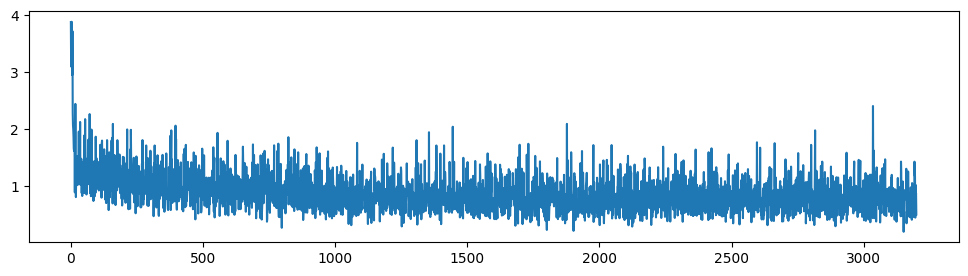

In [15]:
plt.figure(figsize=(12, 3))
plt.plot(losses)

# Submission

In [16]:
model.eval()
test_dataset = CountingVQADataset(test_df, image_processor, tokenizer)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

In [17]:
predictions = []
with torch.no_grad():
    pbar = tqdm(test_loader, desc="Generating predictions")
    for batch in pbar:
        pixel_values = batch["pixel_values"].to(device)
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        pred = model(pixel_values, input_ids, attention_mask).squeeze().item()
        pred = max(0, int(round(pred)))
        predictions.append(pred)

Generating predictions: 100%|██████████| 367/367 [00:03<00:00, 93.10it/s]


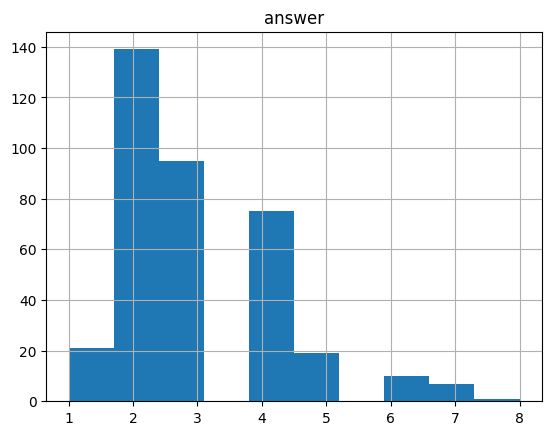

In [18]:
submission_df = pd.DataFrame({"sample_id": test_df["sample_id"], "answer": predictions})
submission_df.hist()
submission_df.to_csv(f"{root_path}/submission.csv", index=False)